In [1]:
import pandas as pd
import os
from nilearn import plotting, image, datasets
import matplotlib.pyplot as plt
from pathlib import Path
import numpy as np
import re
import ipywidgets as widgets
from IPython.display import display
from matplotlib.gridspec import GridSpec
from atlasreader import create_output
from matplotlib.colors import ListedColormap, BoundaryNorm
from nilearn.image import new_img_like
from scipy.ndimage import label


The Python package you are importing, AtlasReader, is licensed under the
BSD-3 license; however, the atlases it uses are separately licensed under more
restrictive frameworks.
By using AtlasReader, you agree to abide by the license terms of the
individual atlases. Information on these terms can be found online at:
https://github.com/miykael/atlasreader/tree/master/atlasreader/data



In [2]:
virtueORvice = 'virtues' # vices, virtues
whichStory = "forgot"  
# tunnel, 21styear, prettymouthaffair, prettymouthparanoia, forgot
whichFoundation = '6' # 1 to 7

# 1 to 7 maps onto the following foundations MAC:
# 1 = deference
# 2 = fairness
# 3 = family
# 4 = group
# 5 = heroism
# 6 = property
# 7 = reciprocity

# output directory
base_dir1 = os.path.expanduser(
    "~/Library/CloudStorage/GoogleDrive-s.h.p.collin@tilburguniversity.edu/My Drive/research/ongoing/2024_shapesNarrativeMRI/__narratives_and_values_fMRI/wholeBrain_results/result_interpretation/"
)

output_dir = Path(f"{base_dir1}{virtueORvice}/vsBaseline/{whichFoundation}/{whichStory}/")

# make the output directory if it does not exist: 
output_dir.mkdir(parents=True, exist_ok=True)

# results directory

if virtueORvice == 'virtues':
    virtueORviceDataFolder = '7_MAC'

if virtueORvice == 'vices':
    virtueORviceDataFolder = '7_MAC_V'

base_dir2 = os.path.expanduser(
    "~/Library/CloudStorage/GoogleDrive-s.h.p.collin@tilburguniversity.edu/My Drive/research/ongoing/2024_shapesNarrativeMRI/__narratives_and_values_fMRI/wholeBrain_results/processed_first_level_per_sentence/"
)

results_dir = Path(f"{base_dir2}{whichStory}/{virtueORviceDataFolder}/SecondLevel_contrast/")


In [3]:
results_dir

PosixPath('/Users/silvycollin/Library/CloudStorage/GoogleDrive-s.h.p.collin@tilburguniversity.edu/My Drive/research/ongoing/2024_shapesNarrativeMRI/__narratives_and_values_fMRI/wholeBrain_results/processed_first_level_per_sentence/forgot/7_MAC/SecondLevel_contrast')

In [4]:
contrast_files = sorted(
    results_dir.glob(f"*foundation{whichFoundation}_VsBaseline_fdrcorrect_per_sentence_MAC*")
)

print(f"Found {len(contrast_files)} contrast maps.")


Found 1 contrast maps.


In [5]:
contrast_files

[PosixPath('/Users/silvycollin/Library/CloudStorage/GoogleDrive-s.h.p.collin@tilburguniversity.edu/My Drive/research/ongoing/2024_shapesNarrativeMRI/__narratives_and_values_fMRI/wholeBrain_results/processed_first_level_per_sentence/forgot/7_MAC/SecondLevel_contrast/threshold_3.4_SecondLevel_forgot_foundation5_VsBaseline_fdrcorrect_per_sentence_MACVirtues.nii.gz')]

In [6]:
for f in contrast_files:
    print(f)
    create_output(
        str(f),
        cluster_extent=2,
        direction="pos",
        outdir=str(output_dir)
    )


/Users/silvycollin/Library/CloudStorage/GoogleDrive-s.h.p.collin@tilburguniversity.edu/My Drive/research/ongoing/2024_shapesNarrativeMRI/__narratives_and_values_fMRI/wholeBrain_results/processed_first_level_per_sentence/forgot/7_MAC/SecondLevel_contrast/threshold_3.4_SecondLevel_forgot_foundation5_VsBaseline_fdrcorrect_per_sentence_MACVirtues.nii.gz


/opt/anaconda3/envs/renv/lib/python3.12/site-packages/atlasreader/atlasreader.py:496: FutureWarning: From release 0.13.0 onwards, this function will, by default, copy the header of the input image to the output. Currently, the header is reset to the default Nifti1Header. To suppress this warning and use the new behavior, set `copy_header=True`.
  thresh_img = image.threshold_img(stat_img, threshold=voxel_thresh)
/opt/anaconda3/envs/renv/lib/python3.12/site-packages/atlasreader/atlasreader.py:496: FutureWarning: From release 0.13.0 onwards, this function will, by default, copy the header of the input image to the output. Currently, the header is reset to the default Nifti1Header. To suppress this warning and use the new behavior, set `copy_header=True`.
  thresh_img = image.threshold_img(stat_img, threshold=voxel_thresh)


## make brain image

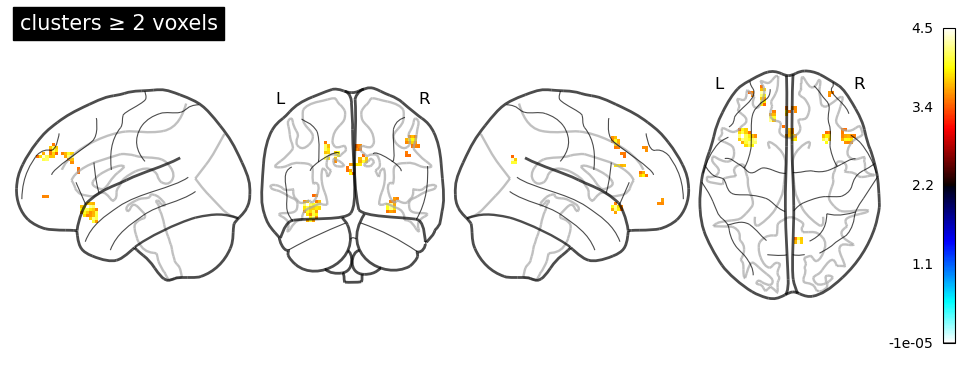

In [7]:
stat_img = image.load_img(contrast_files[0])

# Extract data and affine
data = stat_img.get_fdata()
affine = stat_img.affine

# Label connected clusters
labeled_array, num_features = label(data > 0)  # detects all nonzero clusters

# Keep only clusters with ≥2 voxels
filtered_data = np.zeros_like(data)
for cluster_idx in range(1, num_features + 1):
    cluster_mask = labeled_array == cluster_idx
    if cluster_mask.sum() >= 2:
        filtered_data[cluster_mask] = data[cluster_mask]

# Create filtered image
filtered_img = image.new_img_like(stat_img, filtered_data)

# Plot
display = plotting.plot_glass_brain(
    filtered_img,
    colorbar=True,
    display_mode='lyrz',
    plot_abs=False,
    cmap='cold_hot',
    title='clusters ≥ 2 voxels'
)


# Save as PNG
display.savefig(str(output_dir)+'/glass_brain_clusters_min2vox.png', dpi=300)  
  


plt.show()

display.close()
